# BERTopic (frame detection)

### Preliminary Trail

In [5]:
import pandas as pd
import numpy as np

from bertopic.representation import KeyBERTInspired
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer

In [6]:
df = pd.read_csv("Data/df_zondertips.csv")
df.head()

,ID,Source_File,Newspaper,Date,Length,Section,Author,Edition,Headline,Graphic,Article,Year,length_numeric
0,1,C:\Users\HUAWEI\AppData\Local\Temp\RtmpcBecgr/...,De Telegraaf,2020-06-20,512 words,BINNENLAND; Blz. 8,John van den Heuvel,NaN,'Coke-opa' baas waterbedrijf; OM: Willem van d...,False,Willem G 77 spil grote smokkelzaak John den He...,2020,512
1,2,C:\Users\HUAWEI\AppData\Local\Temp\RtmpcBecgr/...,De Telegraaf,2020-07-11,119 words,BINNENLAND; Blz. 1,John van den Heuvel en Mick van Wely,NaN,'Aanpak misdaad faalde',False,John den Heuvel Mick Wely AMSTERDAM Binnen kwa...,2020,119
2,3,C:\Users\HUAWEI\AppData\Local\Temp\RtmpcBecgr/...,de Volkskrant,2020-06-19,2299 words,"Ten Eerste; Blz. 12, 13",DOOR ANNEKE STOFFELEN,NaN,"'Aanvallen', sprak de profeet in de droom",False,Reconstructie Verijdelde aanslag schieten gek ...,2020,2299
3,4,C:\Users\HUAWEI\AppData\Local\Temp\RtmpcBecgr/...,De Telegraaf,2020-06-02,1093 words,BINNENLAND; Blz. 2,NaN,NaN,"'Als er gedonder was, riep je Orm'; 'Lekagent'...",False,Lekagent eerder onderzocht wegens cowboygedrag...,2020,1093
4,5,C:\Users\HUAWEI\AppData\Local\Temp\RtmpcBecgr/...,AD/Algemeen Dagblad,2017-10-11,212 words,Nieuwsdienst; Blz. 5,ARJEN TEN CATE GERALD MEIJER,NaN,"'Als kind was hij aardig, maar door drugsgebru...",False,telefoonwinkel Zeewolde staat jongeman pet ken...,2017,212


In [7]:
embedding_model = SentenceTransformer("LoicDL/NewsBERTje-base")

representation_model = KeyBERTInspired()

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

vectorizer_model = CountVectorizer(
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 3)
)

documents = df["Article"].to_list()

No sentence-transformers model found with name /home/20236408/.cache/torch/sentence_transformers/LoicDL_NewsBERTje-base. Creating a new one with MEAN pooling.
Some weights of BertModel were not initialized from the model checkpoint at /home/20236408/.cache/torch/sentence_transformers/LoicDL_NewsBERTje-base and are newly initialized: ['bert.pooler.dense.weight', 'bert.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [4]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    ctfidf_model=ctfidf_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    language="dutch",
    min_topic_size=25,
    n_gram_range=(1, 3),
    top_n_words=15,
    nr_topics="auto",
)

In [5]:
topics, probs = topic_model.fit_transform(documents)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

In [6]:
new_topics = topic_model.reduce_outliers(
    documents, topics,
    strategy="c-tf-idf",
    threshold=0.3
)

topic_model.update_topics(documents, topics=new_topics,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model)

2026-05-18 18:05:48,088 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [7]:
info = topic_model.get_topic_info()

bertopic_df = info[["Topic", "Name", "Representation", "Representative_Docs", "Count"]]

bertopic_df.to_csv("topics_summary.csv", index=False)
print("Saved topics_summary_based_ctfidf.csv")
print(bertopic_df)

Saved topics_summary_based_ctfidf.csv
    Topic                                               Name  \
0      -1                     -1_loopt_amsterdamse_boek_film   
1       0                           0_loopt_boek_jongen_film   
2       1  1_kilo cocaïne onderschept_rotterdamse haven_k...   
3       2  2_graham norton show_spuiten slikken_graham no...   
4       3  3_hells angels satudarah_outlaw motorcycle gan...   
5       4  4_giovanni falcone_siciliaanse maffia_italiaan...   
6       5  5_mexicaanse drugsbaron_joaquín el chapo_joaqu...   
7       6  6_man bleek_moest rijbewijs_rijbewijs inlevere...   
8       7  7_strépy bracquegnies_rijverbod_bracquegnies_i...   
9       8  8_nederlandse marineschip zr_marineschip zr ms...   
10      9  9_street new york_farmaceut_wall street_dow jones   
11     10  10_schietincidenten_inbrekers straatrovers_aan...   
12     11  11_paul eldering schiphol_eldering schiphol_pa...   
13     12  12_boogschutter_verplichtingen_moeite kosten_m...   
14

In [8]:
topic_model.visualize_hierarchy()

In [9]:
topic_model.get_topics()

{-1: [('loopt', np.float32(0.6310962)),
  ('amsterdamse', np.float32(0.62649196)),
  ('boek', np.float32(0.5996347)),
  ('film', np.float32(0.58541024)),
  ('jongen', np.float32(0.5841053)),
  ('niks', np.float32(0.5619104)),
  ('amerikaanse', np.float32(0.5614668)),
  ('vertellen', np.float32(0.56115365)),
  ('alsof', np.float32(0.5520928)),
  ('praten', np.float32(0.5473734))],
 0: [('loopt', np.float32(0.63147914)),
  ('boek', np.float32(0.60243076)),
  ('jongen', np.float32(0.59981394)),
  ('film', np.float32(0.5929498)),
  ('amerikaanse', np.float32(0.5733817)),
  ('kamer', np.float32(0.5652049)),
  ('veroordeeld', np.float32(0.5625568)),
  ('niks', np.float32(0.5542572)),
  ('geeft', np.float32(0.5464926)),
  ('alsof', np.float32(0.5463035))],
 1: [('kilo cocaïne onderschept', np.float32(0.7441326)),
  ('rotterdamse haven', np.float32(0.72714955)),
  ('kilo cocaïne gevonden', np.float32(0.71827245)),
  ('douane rotterdamse', np.float32(0.7052463)),
  ('bestand document rotterdam'

In [10]:
# Date preperation
df["Date"] = pd.to_datetime(df["Date"])     # ensure datetime
df["Year"] = df["Date"].dt.to_period("Y").dt.to_timestamp() # Otherwise too computational expensive

document = df["Article"].tolist()
timestamps = df["Year"].tolist()

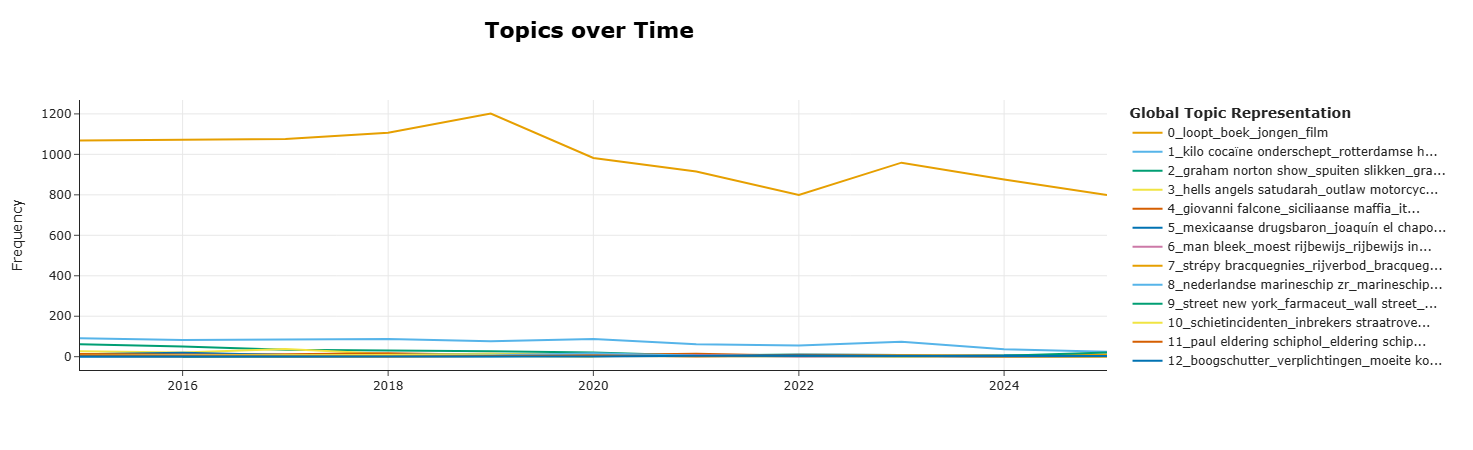

In [11]:
# Compute topics over time
topics_over_time = topic_model.topics_over_time(
    docs=documents,
    timestamps=df["Year"].tolist(),
    global_tuning=False,
    evolution_tuning=False,
)

# Visualize
fig = topic_model.visualize_topics_over_time(
    topics_over_time,
    top_n_topics=50,           # or fewer if you want a cleaner plot
)
fig.show()

### KeyBERT Inspired (Different Newspaper)

In [1]:
from bertopic import BERTopic
import pandas as pd
import plotly.express as px

from sentence_transformers import SentenceTransformer
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import KeyBERTInspired
from sklearn.feature_extraction.text import CountVectorizer

from umap import UMAP
from hdbscan import HDBSCAN

In [2]:
df = pd.read_csv("Data/df_zondertips.csv")
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year

newspapers = df["Newspaper"].unique()
print(f"Found {len(newspapers)} newspapers: {newspapers}")

embedding_model = SentenceTransformer("LoicDL/NewsBERTje-base")

def make_ctfidf():
    return ClassTfidfTransformer(reduce_frequent_words=True)

def make_vectorizer():
    return CountVectorizer(
        min_df=2,
        max_df=0.8,
        ngram_range=(1, 3)
    )

representation_model = KeyBERTInspired()

def make_umap():
    return UMAP(
        n_neighbors=15,
        n_components=5,
        min_dist=0.0,
        metric='cosine',
        random_state=42
    )

def make_hdbscan():
    return HDBSCAN(
        min_cluster_size=8,
        min_samples=2,
        metric='euclidean',
        cluster_selection_method='leaf',
        prediction_data=True
    )

Found 3 newspapers: <StringArray>
['De Telegraaf', 'de Volkskrant', 'AD/Algemeen Dagblad']
Length: 3, dtype: str


No sentence-transformers model found with name /home/20236408/.cache/torch/sentence_transformers/LoicDL_NewsBERTje-base. Creating a new one with MEAN pooling.
Some weights of BertModel were not initialized from the model checkpoint at /home/20236408/.cache/torch/sentence_transformers/LoicDL_NewsBERTje-base and are newly initialized: ['bert.pooler.dense.weight', 'bert.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [4]:
newspaper_models = {}
newspaper_topics = {}
all_topic_info = []

for newspaper in newspapers:
    df_paper = df[df["Newspaper"] == newspaper].copy().reset_index(drop=True)
    documents = df_paper["Article"].fillna("").tolist()

    print(f"\nProcessing {newspaper} — {len(documents)} articles")
    if len(documents) < 100:
        print(f"  Skipping {newspaper} — too few articles")
        continue

    # Fresh UMAP and HDBSCAN per newspaper 
    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=make_umap(),
        hdbscan_model=make_hdbscan(),
        ctfidf_model=make_ctfidf(),
        vectorizer_model=make_vectorizer(),
        representation_model=representation_model,
        language="dutch",
        min_topic_size=10,
        n_gram_range=(1, 3),
        top_n_words=15,
        nr_topics="None",
        calculate_probabilities=False
    )

    topics, probs = topic_model.fit_transform(documents)

    # ── Topic info ────────────────────────────────────────────────────────────
    topic_info = topic_model.get_topic_info()
    topic_info = topic_info[
        ["Topic", "Name", "Representation", "Representative_Docs", "Count"]
    ].copy()
    topic_info["Newspaper"] = newspaper
    topic_info = topic_info.rename(columns={
        "Topic": "topic_id",
        "Name": "topic_name",
        "Representation": "representation",
        "Representative_Docs": "representation_docs",
        "Count": "count",
        "Newspaper": "newspaper"
    })
    topic_info = topic_info[[
        "newspaper", "topic_id", "topic_name",
        "representation", "representation_docs", "count"
    ]]
    all_topic_info.append(topic_info)

    n_noise = (topic_info["topic_id"] == -1).sum()
    n_topics = (topic_info["topic_id"] != -1).sum()
    print(f"  Topics found: {n_topics} | Noise (-1): {n_noise}")
    print(topic_info.head(10))

# ── Save combined newspaper topics ────────────────────────────────────────────
topics_by_newspaper = pd.concat(all_topic_info, ignore_index=True)
topics_by_newspaper.to_csv("topics_by_newspaper.csv", index=False)
print("\nSaved topics_by_newspaper.csv")


Processing De Telegraaf — 10485 articles
  Topics found: 28 | Noise (-1): 1
      newspaper  topic_id                                         topic_name  \
0  De Telegraaf        -1                           -1_man_zitten_kreeg_huis   
1  De Telegraaf         0                            0_man_zitten_kreeg_ging   
2  De Telegraaf         1  1_street new york_farmaceut_wall street_bank a...   
3  De Telegraaf         2  2_boogschutter_verplichtingen_moeite kosten_mo...   
4  De Telegraaf         3  3_siciliaanse cosa nostra_siciliaanse maffia_s...   
5  De Telegraaf         4  4_hells angels satudarah_satudarah hells angel...   
6  De Telegraaf         5  5_bokser floyd mayweather_leeuwarder courant_b...   
7  De Telegraaf         6  6_legaliseren marcel_bisschop ophoviusstraat t...   
8  De Telegraaf         7  7_dumpingen drugsafval_niels rigter_drugslabor...   
9  De Telegraaf         8  8_spirit ecstasy_range rover_auto ter_mercedes...   

                                      repr

In [4]:
# ── Dynamic topic modeling per newspaper ──────────────────────────────────────
print("\nRunning dynamic topic modeling per newspaper...")
newspaper_dynamic = {}

for newspaper, topic_model in newspaper_models.items():
    df_paper = df[df["Newspaper"] == newspaper].copy().reset_index(drop=True)
    documents = df_paper["Article"].fillna("").tolist()
    timestamps = df_paper["Year"].tolist()  # use Year (period timestamp) to match corpus pipeline

    print(f"\nDynamic topics for {newspaper}...")
    topics_over_time = topic_model.topics_over_time(
        documents,
        timestamps,
        nr_bins=10,
        global_tuning=True,   # aligned with corpus pipeline (was False)
        evolution_tuning=True
    )
    newspaper_dynamic[newspaper] = topics_over_time


Running dynamic topic modeling per newspaper...

Dynamic topics for De Telegraaf...

Dynamic topics for de Volkskrant...

Dynamic topics for AD/Algemeen Dagblad...


In [5]:
# ── Dynamic topic modeling per newspaper ──────────────────────────────────────
print("\nRunning dynamic topic modeling per newspaper...")
newspaper_dynamic = {}

for newspaper, topic_model in newspaper_models.items():
    df_paper = df[df["Newspaper"] == newspaper].copy().reset_index(drop=True)
    documents = df_paper["Article"].fillna("").tolist()
    timestamps = df_paper["Year"].tolist()  # use Year (period timestamp) to match corpus pipeline

    print(f"\nDynamic topics for {newspaper}...")
    topics_over_time = topic_model.topics_over_time(
        documents,
        timestamps,
        nr_bins=10,
        global_tuning=True,   # aligned with corpus pipeline (was False)
        evolution_tuning=True
    )
    newspaper_dynamic[newspaper] = topics_over_time

In [6]:
import pandas as pd

topics_by_newspaper_df=pd.read_csv("topics_by_newspaper.csv")

# 1. Show noise row (topic_id == -1) 
noise_row = topics_by_newspaper_df[topics_by_newspaper_df["topic_id"] == 3]
print("Noise row:")
print(noise_row[["newspaper", "topic_name", "count", "representation"]])

# 2. Show example representative docs from noise
print("\nNoise representative docs:")
print(noise_row["representation_docs"].iloc[0])

# 3. Compare to valid topics in same newspaper
newspaper = noise_row["newspaper"].iloc[0]  # first noise newspaper
print(f"\nTop topics in {newspaper}:")
print(topics_by_newspaper_df[topics_by_newspaper_df["newspaper"] == newspaper].nsmallest(5, "count")[["topic_id", "topic_name", "count"]])

Noise row:
              newspaper                                         topic_name  \
4          De Telegraaf            3_fentanyl_oxycodon_verslavend_opioïden   
85        de Volkskrant            3_cakejes_marie louise_jef_langoustines   
91  AD/Algemeen Dagblad  3_drugstransporten onderschept_kilo cocaïne on...   

    count                                     representation  
4      71  ['fentanyl', 'oxycodon', 'verslavend', 'opioïd...  
85     16  ['cakejes', 'marie louise', 'jef', 'langoustin...  
91     45  ['drugstransporten onderschept', 'kilo cocaïne...  

Noise representative docs:
["Vernietigende killer vooralsnog legaal verkrijgbaar nieuwe drug 3-MMC overspoelt Oost-Nederland Vooral jongeren raken greep zogeheten partydrug één verslavingsklinieken regio veertig procent patiënten problemen gekomen 3-MMC 3-MMC spotgoedkoop verdovend middel vernietigende effecten verslavingszorg slaat alarm drug vooralsnog legaal bestrijding dweilen kraan open jongeren gesproken drie nach

## Thesis Choice w/ Hyperparameter Tuning

In [8]:
from umap import UMAP
from hdbscan import HDBSCAN

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=10,    # was 25/30 — allows smaller clusters to form
    min_samples=2,          # was defaulting high — core point threshold lowered
    metric='euclidean',
    cluster_selection_method='leaf',  # finds more granular clusters than 'eom'
    prediction_data=True
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    ctfidf_model=ctfidf_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    language="dutch",
    min_topic_size=10,       # align with hdbscan
    n_gram_range=(1, 3),
    top_n_words=15,
    nr_topics="auto",
    calculate_probabilities=False  # keep off — avoids the collapse problem
)

topics, probs = topic_model.fit_transform(documents)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

In [10]:
new_topics = topic_model.reduce_outliers(
    documents, topics,
    strategy="c-tf-idf",
    threshold=0.3
)

topic_model.update_topics(documents, topics=new_topics,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model)

info = topic_model.get_topic_info()

df["topic_id"] = topics                          # ← save mapping
df.to_csv("df_with_topics.csv", index=False)
topic_model.save("global_bertopic")       # ← save model

bertopic_df_2 = info[["Topic", "Name", "Representation", "Representative_Docs", "Count"]]

bertopic_df_2.to_csv("topics_summary_2.csv", index=False)
print("Saved topics_summary_2.csv")
print(bertopic_df_2)

2026-05-21 14:37:05,870 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.
2026-05-21 14:40:48,304 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Saved topics_summary_2.csv
     Topic                                               Name  \
0       -1                              -1_boek_zat_huis_film   
1        0     0_ridouan taghi_amsterdamse_rotterdamse_bewijs   
2        1                              1_film_boek_zat_plaat   
3        2  2_venezolaanse president_president rodrigo dut...   
4        3        3_michael mann_oscarnominatie_scorsese_film   
..     ...                                                ...   
399    398  398_benidorm bastard_geert jan knoops_voormali...   
400    399  399_pro formazitting amsterdam_wapenvondst nie...   
401    400  400_dimitri verhulst_afwijking waarbij_arthur ...   
402    401  401_godfather sopranos_providence rhode island...   
403    402  402_later overleed volgens_festival zerotolera...   

                                        Representation  \
0    [boek, zat, huis, film, weinig, amerikaanse, d...   
1    [ridouan taghi, amsterdamse, rotterdamse, bewi...   
2    [film, boek, 

In [24]:
# Date preperation
df["Date"] = pd.to_datetime(df["Date"])     # ensure datetime
df["Year"] = df["Date"].dt.to_period("Y").dt.to_timestamp() # Otherwise too computational expensive

timestamps = df["Year"].tolist()

In [25]:
# Compute topics over time
topics_over_time = topic_model.topics_over_time(
    docs=documents,
    timestamps=df["Year"].tolist(),
    global_tuning=True,
    evolution_tuning=True,
)

# Visualize
fig = topic_model.visualize_topics_over_time(
    topics_over_time,
    top_n_topics=50,           # or fewer if you want a cleaner plot
)
fig.show()

## Newspaper-Level on Whole Corpus

In [1]:
import pandas as pd
import plotly.express as px
from scipy.stats import chi2_contingency
import openpyxl

In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv("df_with_topics.csv")
classifications = pd.read_excel(
    "topic_classifications.xlsx",
    sheet_name="Classifications"
)[["Topic ID", "Frame Category"]].rename(columns={"Topic ID": "topic_id"})

In [3]:
# ── Merge frame categories onto article-level data ────────────────────────────
df = df.merge(classifications, on="topic_id", how="left")

# Drop algorithmic noise (-1) and uninterpretable NOISE topics
df_frame = df[~df["Frame Category"].isin(["NOISE_ALGO", "NOISE"])].copy()

print(f"Articles with frame: {len(df_frame):,}")
print(df_frame.groupby("Newspaper")["topic_id"].count())

Articles with frame: 12,155
Newspaper
AD/Algemeen Dagblad    3195
De Telegraaf           4904
de Volkskrant          4056
Name: topic_id, dtype: int64


In [4]:
# ── Proportional frame distribution per newspaper ─────────────────────────────
counts = (
    df_frame
    .groupby(["Newspaper", "Frame Category"])
    .size()
    .reset_index(name="count")
)
counts["share"] = counts.groupby("Newspaper")["count"].transform(
    lambda x: x / x.sum()
)

# Wide format table
frame_dist = (
    counts
    .pivot(index="Newspaper", columns="Frame Category", values="share")
    .fillna(0)
    .round(3)
)
print("\nProportional frame distribution per newspaper:")
print(frame_dist.to_string())


Proportional frame distribution per newspaper:
Frame Category       Crime & Criminal Justice  Drug Policy & Politics  Entertainment & Pop Culture  Public Health & Addiction
Newspaper                                                                                                                    
AD/Algemeen Dagblad                     0.442                   0.154                        0.293                      0.111
De Telegraaf                            0.524                   0.204                        0.190                      0.083
de Volkskrant                           0.222                   0.232                        0.430                      0.116


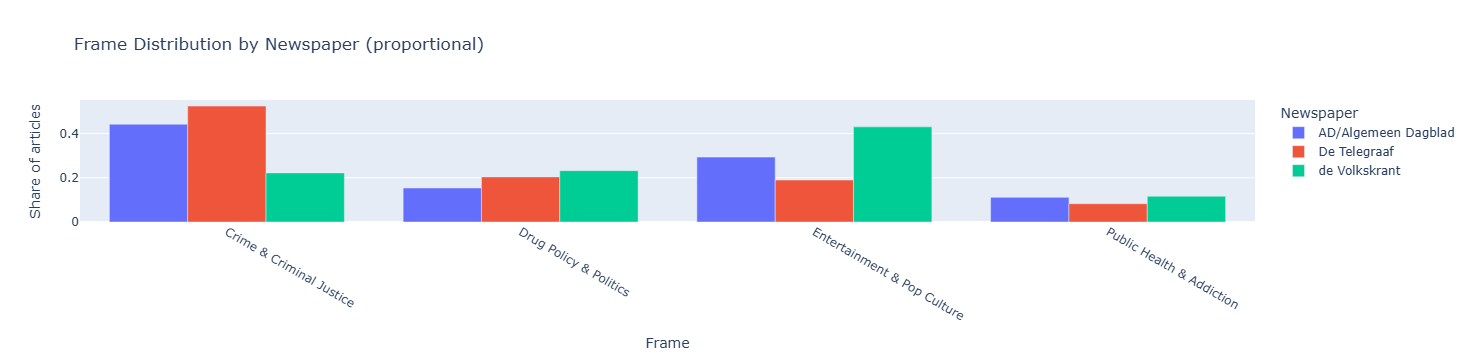

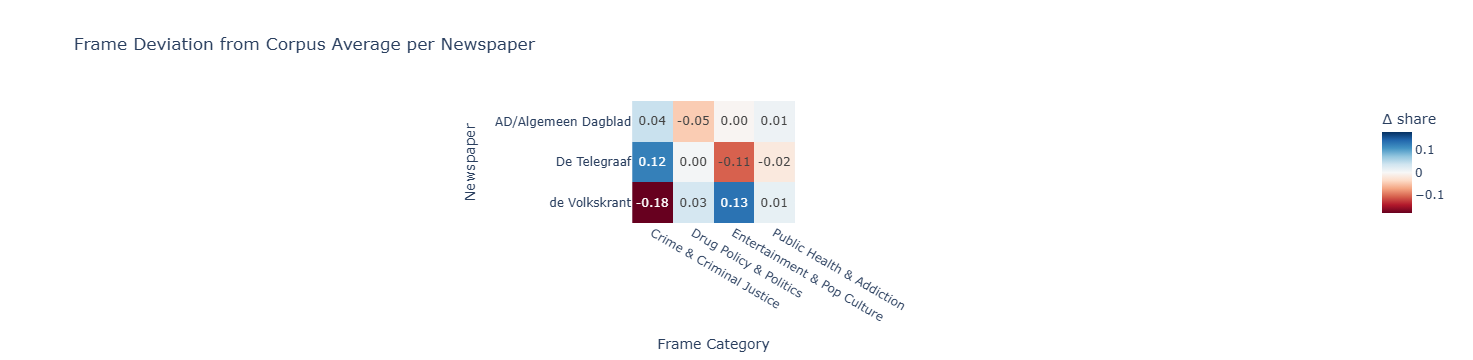

In [5]:
# ── Plot 1: grouped bar ───────────────────────────────────────────────────────
fig1 = px.bar(
    counts, x="Frame Category", y="share",
    color="Newspaper", barmode="group",
    title="Frame Distribution by Newspaper (proportional)",
    labels={"share": "Share of articles", "Frame Category": "Frame"},
)
fig1.update_xaxes(tickangle=30)
fig1.show()

# ── Plot 2: deviation from corpus average ─────────────────────────────────────
corpus_avg = df_frame["Frame Category"].value_counts(normalize=True)
deviation = frame_dist.subtract(corpus_avg, axis=1)

fig2 = px.imshow(
    deviation,
    color_continuous_scale="RdBu",
    color_continuous_midpoint=0,
    title="Frame Deviation from Corpus Average per Newspaper",
    labels={"color": "Δ share"},
    text_auto=".2f"
)
fig2.show()

In [6]:
# ── Statistical test ──────────────────────────────────────────────────────────
count_pivot = counts.pivot(
    index="Newspaper", columns="Frame Category", values="count"
).fillna(0).astype(int)

chi2, p, dof, _ = chi2_contingency(count_pivot)
print(f"\nChi-square: χ²={chi2:.2f}, df={dof}, p={p:.4e}")


Chi-square: χ²=1037.80, df=6, p=5.9636e-221


## Spotting Trends throughout Years

In [6]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [7]:
# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv("Data/df_with_topics.csv")
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year

classifications = pd.read_excel(
    "topic_classifications.xlsx",
    sheet_name="Classifications"
)[["Topic ID", "Frame Category"]].rename(columns={"Topic ID": "topic_id"})

df = df.merge(
    classifications[~classifications["Frame Category"].isin(["NOISE","NOISE_ALGO"])],
    on="topic_id", how="inner"
)

FRAME_COLORS = {
    "Crime & Criminal Justice":    "#E06666",
    "Drug Policy & Politics":      "#93C47D",
    "Public Health & Addiction":   "#FFD966",
    "Entertainment & Pop Culture": "#C27BA0",
}
NP_COLORS = {
    "AD/Algemeen Dagblad": "#6FA8DC",
    "De Telegraaf":        "#E06666",
    "de Volkskrant":       "#93C47D",
}
FRAMES     = list(FRAME_COLORS.keys())
NEWSPAPERS = list(df["Newspaper"].unique())

In [8]:
# ── Helper: compute share table ───────────────────────────────────────────────
def frame_shares(data):
    yf = (
        data.groupby(["Year","Frame Category"])
        .size().reset_index(name="count")
    )
    yf["share"] = yf.groupby("Year")["count"].transform(
        lambda x: x / x.sum()
    )
    return yf

In [9]:
# One range computed from ALL data — global and per-newspaper combined
all_shares = pd.concat([
    frame_shares(df)["share"],
    *[frame_shares(df[df["Newspaper"]==n])["share"] for n in NEWSPAPERS]
])
y_min = 0
y_max = round(all_shares.max() + 0.03, 2)

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1 — Global: all 4 frames over time
# ─────────────────────────────────────────────────────────────────────────────
fig1 = px.line(
    frame_shares(df), x="Year", y="share",
    color="Frame Category", markers=True,
    labels={"share": "Share of framed articles", "Frame Category": "Frame"},
    color_discrete_map=FRAME_COLORS
)
fig1.update_layout(
    yaxis=dict(tickformat=".0%", range=[y_min, y_max]),
    xaxis=dict(dtick=1),
    width=1000, height=500,
    margin=dict(l=50, r=150, t=30, b=50),
    legend=dict(x=1.02, y=0.5, xanchor='left', yanchor='middle'),
    font=dict(size=14)
)
fig1.write_image("Output/FrameOverTime.png", scale=2)

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2 — Per newspaper: individual 4-line charts
# ─────────────────────────────────────────────────────────────────────────────
for newspaper in NEWSPAPERS:
    df_np = df[df["Newspaper"] == newspaper]
    fig = px.line(
        frame_shares(df_np), x="Year", y="share",
        color="Frame Category", markers=True,
        labels={"share": "Share of framed articles", "Frame Category": "Frame"},
        color_discrete_map=FRAME_COLORS
    )
    fig.update_layout(
        yaxis=dict(tickformat=".0%", range=[y_min, y_max]),
        xaxis=dict(dtick=1),
        width=1000, height=500,
        margin=dict(l=50, r=150, t=30, b=50),
        legend=dict(x=1.02, y=0.5, xanchor='left', yanchor='middle'),
        font=dict(size=14)
    )
    safe = newspaper.replace("/", "_").replace(" ", "_")
    fig.write_image(f"Output/FrameOverTime_{safe}.png", scale=2)

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 3 — Comparative 2x2
# Each panel has its own y range (frames differ too much for a shared range)
# ─────────────────────────────────────────────────────────────────────────────
fig3 = make_subplots(
    rows=2, cols=2,
    subplot_titles=FRAMES,
    shared_xaxes=True, shared_yaxes=False,
    vertical_spacing=0.15, horizontal_spacing=0.1
)
positions = {
    FRAMES[0]: (1,1), FRAMES[1]: (1,2),
    FRAMES[2]: (2,1), FRAMES[3]: (2,2)
}
for newspaper in NEWSPAPERS:
    df_np  = df[df["Newspaper"] == newspaper]
    shares = frame_shares(df_np)
    color  = NP_COLORS.get(newspaper, "#888888")
    for frame, (row, col) in positions.items():
        sub = shares[shares["Frame Category"]==frame].sort_values("Year")
        fig3.add_trace(
            go.Scatter(
                x=sub["Year"], y=sub["share"],
                name=newspaper,
                line=dict(color=color),
                marker=dict(size=6),
                legendgroup=newspaper,
                showlegend=(frame == FRAMES[0]),
            ),
            row=row, col=col
        )
for frame, (row, col) in positions.items():
    panel_shares = []
    for newspaper in NEWSPAPERS:
        sub = frame_shares(df[df["Newspaper"]==newspaper])
        sub = sub[sub["Frame Category"]==frame]["share"]
        panel_shares.extend(sub.tolist())
    p_min = max(0, round(min(panel_shares) - 0.02, 2))
    p_max = round(max(panel_shares) + 0.02, 2)
    fig3.update_yaxes(
        tickformat=".0%",
        range=[p_min, p_max],
        row=row, col=col
    )
fig3.update_xaxes(dtick=1)
fig3.update_layout(
    height=700, width=1100,
    margin=dict(l=50, r=150, t=50, b=50),
    font=dict(size=14)
)
fig3.write_image("Output/FrameOverTime_Comparative.png", scale=2)

print("All figures saved to Output/")

All figures saved to Output/
